# Проект спринта 10: Тортилла. Модель предстаказания массы черепах.



Центр исследования и реабилитации морских черепах «Тортилла» объявил конкурс на разработку модели машинного обучения, которая будет предсказывать массу морских черепах бесконтактным способом.

Партнёры центра «Тортилла» из «Лаборатории перспективных технологий института океанографии» разработали портативную систему компьютерного зрения TurtleCV, которая будет с высокой точностью бесконтактно измерять габариты черепах.

Подсистема компьютерного зрения определяет:
- длину и ширину панциря в миллиметрах (мм);
- габариты головы (мм);
- габариты ласт (мм);
- количество колец на щитках панциря.

Необходимо разработать модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

## Постановка задачи машинного обучения

- Задача: разработать модель линейной регрессии.
- Целевая переменная: масса черепахи.
- Основная метрика качества модели: MAE.
- Дополнительные метрика качества модели: MSE, R², MAPE.
- Критерии успешности: для целевой популяции зелёных морских черепах массой от 50 до 150 - **MAE не более 5 кг**, **R² не менее 0.97**.

## Описание датасета

Датасет находится в CSV-файле и доступен по ссылке 'https://code.s3.yandex.net/datasets/turtles.csv'.

**Атрибуты:**

`id` — идентификатор измерения.  

`binomial_name` — международное научное название вида черепахи.  

`registration_number` — регистрационный номер черепахи.  

`shell_length` — длина панциря, мм.  

`shell_width` — ширина панциря, мм.  

`head_length` — длина головы, мм.  

`head_width` — ширина головы, мм.  

`flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  

`flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  

`circle_count` — количество колец роста на панцире черепахи.  

`measure_count` — количество измерений по модели компьютерного зрения перед усреднением показателей.  

`shell_crack` — наличие трещин панциря.  

`timestamp` — время внесения данных о черепахе.  

`weight` — масса черепахи, кг.  


## Содержимое проекта

1. Загрузка данных и знакомство с ними  


---

## Подключение и настройка библиотек

In [1]:
# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns



## Загрузка датасета

- Загрузим данные из файла `turtles.csv` методаом [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). Установим правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверим, правильно ли прошла загрузка. Данные должны соответствовать описанию.
- С помощью методов библиотеки pandas выведем общие сведения о данных.
- Проведем ознакомление с датасетом. Возможно ли продолжать с ним работу? Если нет — что нужно сделать?

In [2]:
df_turtles = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

In [3]:
df_turtles.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [4]:
df_turtles.columns = df_turtles.columns.str.replace(' ', '_')

In [5]:
df_turtles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

In [6]:
measure_cols_float = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'measure_count', 'shell_crack', 'weight']
for col in measure_cols_float:
    df_turtles[col] = pd.to_numeric(df_turtles[col], downcast='float')

measure_cols_int = ['circle_count']
for col in measure_cols_int:
    df_turtles[col] = pd.to_numeric(df_turtles[col], downcast='integer')


df_turtles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float32
 4   shell_width          8861 non-null   float32
 5   head_length          8715 non-null   float32
 6   head_width           8715 non-null   float32
 7   flipper_length_1     8861 non-null   float32
 8   flipper_width_1      8861 non-null   float32
 9   flipper_length_2     8861 non-null   float32
 10  flipper_width_2      8861 non-null   float32
 11  flipper_length_3     8760 non-null   float32
 12  flipper_width_3      8760 non-null   float32
 13  flipper_length_4     8760 non-null   float32
 14  flipper_width_4      8760 non-null   float32
 15  circle_count         8861 non-null   int16  
 16 

## Комментарий по итогам загрузки

1) Загрузка датасета `turtle.csv`  по указанному пути прошла нормально. Данные соответствуют описанию.
2) Датасет содержит **20 атрибутов** и **8 861 строку**.  
3) В наименовани поля `registration number` заменили пропуск ' ' на '_'. Новое название `registration_number`. 
4) Атрибуты с типом данных `int64`: id, shell_width, flipper_length_1, flipper_width_1, flipper_length_2, flipper_width_2, circle_count, timestamp.  
5) Типом данных `str` представлены колонки: binomial_name и registration_number.  
6) К типу `float64` относятся поля: shael_length, head_length, head_width, flipper_length_3, flipper_width_3, flipper_length_4, flipper_width_4, measure_count, shell_crack, weight.  
7) Все числовые атрибуты с замерами длины и ширины были приведены к единому типу `float32`.
8) Тип атрибута с замером числа колец `circle_count` приведен к более оптимальному `int16`.
9) 12 атрибутов из 20 содержат пропуски. Больше всего пропусков в shell_crack.

В датасете необходимо обработать пропуски и проверить на наличие дубликатов.

## Исследовательский анализ данных

Проведите исследовательский анализ данных:

7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### 1. Данные о каких черепахах представлены в датасете

In [7]:
# Проверяем уникальные значения в столбце с видам черепах
print(f'Уникальные значения в столбце binomial_name:')
print(df_turtles['binomial_name'].sort_values().unique())
print('Число уникальных значений:', df_turtles['binomial_name'].sort_values().nunique())
print()

Уникальные значения в столбце binomial_name:
<StringArray>
[       'CARETTA CARETTA',         'CHELONIA MYDAS',        'Caretta Caretta',
        'Caretta caretta',         'Chelonia Mydas',         'Chelonia mydas',
   'DERMOCHELYS CORIACEA',   'Dermochelys Coriacea',   'Dermochelys coriacea',
 'ERETMOCHELYS IMBRICATA', 'Eretmochelys Imbricata', 'Eretmochelys imbricata',
  'LEPIDOCHELYS OLIVACEA',    'Lepidochelys Kempii',  'Lepidochelys Olivacea',
    'Lepidochelys kempii',  'Lepidochelys olivacea',        'caretta caretta',
         'chelonia mydas',   'dermochelys coriacea', 'eretmochelys imbricata',
    'lepidochelys kempii',  'lepidochelys olivacea',                      nan]
Length: 24, dtype: str
Число уникальных значений: 23



In [8]:
# Посмотрим на количество записей по видам черепах
df_turtles['binomial_name'].value_counts()

binomial_name
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: count, dtype: int64

### Комментарий

В названии видов черепах содержатся дубликаты. Нас интересует вид `Chelonia mydas`, который представлен записями в датасете в категориях: *Chelonia mydas* - 2325 строк, *chelonia mydas* - 252 строки, *Chelonia Mydas* - 177 строк, *CHELONIA MYDAS* - 75 строк.
_______

### 2. Проведём отбор записей о виде черепах *Chelonia mydas*

In [9]:
# Прежде всего утсраним дубликаты в названиях черепах
df_turtles['binomial_name'] =  df_turtles['binomial_name'].str.lower()
df_turtles['binomial_name'].unique()

<StringArray>
[       'caretta caretta',  'lepidochelys olivacea',         'chelonia mydas',
 'eretmochelys imbricata',   'dermochelys coriacea',                      nan,
    'lepidochelys kempii']
Length: 7, dtype: str

In [10]:
df_chelodia_mydas = df_turtles[df_turtles['binomial_name'] == 'chelonia mydas'].reset_index(drop=True)
df_chelodia_mydas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   str    
 2   registration_number  2825 non-null   str    
 3   shell_length         2794 non-null   float32
 4   shell_width          2829 non-null   float32
 5   head_length          2790 non-null   float32
 6   head_width           2790 non-null   float32
 7   flipper_length_1     2829 non-null   float32
 8   flipper_width_1      2829 non-null   float32
 9   flipper_length_2     2829 non-null   float32
 10  flipper_width_2      2829 non-null   float32
 11  flipper_length_3     2798 non-null   float32
 12  flipper_width_3      2798 non-null   float32
 13  flipper_length_4     2798 non-null   float32
 14  flipper_width_4      2798 non-null   float32
 15  circle_count         2829 non-null   int16  
 16 

### Комментарий
В датасете устранены неявные дубликаты в названиях черепах `binomial_name`, а затем выделена отдельная выборка только по типу черепах `chelonia mydas`.
__________

### 3. Определим все ли признаки необходимо использовать для решения задачи. Удалим признаки, которые никак не помогут.

In [11]:
df_chelodia_mydas.head()

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352001
1,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074005
2,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695000
3,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.181999
4,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707001


In [12]:
df_chelodia_mydas = df_chelodia_mydas.drop(columns=['binomial_name', 'shell_crack', 'measure_count', 'timestamp'])
df_chelodia_mydas.head()

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
0,25241,0d05dca974d9f624d9c9f8e38817f827,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,56.352001
1,20099,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,154.074005
2,18213,cbb98eb064c1dcefd1a009b21656500f,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,87.695000
3,20656,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,51.181999
4,20839,8c20d754391001ef4cda77701123f4bc,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,92.707001


### Комментарий

Удалим признаки, которые не принесут никакой пользы при построениии модели: `binomial_name` (вид черепах один и тот же, смысла его оставлять нет); `shell_crack` - атрибут содержит большое число пропусков, но также можно с высокой степенью уверенности предположить, что наличие или отсутсвие трещин на панцире не влияет на вес животного; `measure_count` - признак, показывающий число измерений одного животного, на основании которого считались средние показатели, а также `timestamp`, показывающий время замера, не повлияют на итоговую линейною модель.
_________

### 4. Проверим и обработаем пропуски в данных

In [13]:
def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_chelodia_mydas)

,Кол-во пропусков,Доля пропусков
registration_number,4,0.0014
shell_length,35,0.0124
head_length,39,0.0138
head_width,39,0.0138
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110
weight,3,0.0011


In [14]:
df_chelodia_mydas = df_chelodia_mydas.dropna(subset=['weight']).reset_index(drop=True)
show_missing_stats(df_chelodia_mydas)

,Кол-во пропусков,Доля пропусков
registration_number,4,0.0014
shell_length,35,0.0124
head_length,39,0.0138
head_width,39,0.0138
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110


### Комментарий

В датасете обнаружены пропуски в атрибутах `registration_number`, `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`, `measure_count`, `weight`. Число пропусков невелико и составляет немногим более **1%** от общего размера датасета. Самое малое число пропусков обнаружено в поле `weight` - 3 и `registration_number` - 4.

Предполагается неслучайный тип пропусков - `MNAR`. Вероятно связано с проблемами потерь данных при замерах: неработающие датчики, потери при передачи данных в условиях дикой природы и т.п.

**Решение:** на данном этапе удаляем строки с 3 пропусками по массе животных `weight`. Эта цифра, во-первых, незначительна, во-вторых, без массы все остальные признаки для модели не имеют смысла. Нужно оставить все остальные до момента обработки дубликатов и отбора признаков для модели. 
________

### 5. Проверим и обработаем дубликаты

In [15]:
# Проверим наличие явных дубликатов
df_chelodia_mydas.duplicated().sum()

np.int64(340)

In [16]:
df_chelodia_mydas.sort_values(by='registration_number')[df_chelodia_mydas.sort_values(by='registration_number').duplicated(keep=False)]

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
2765,24052,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768.0,117.0,128.0,521.0,489.0,512.0,470.0,411.0,335.0,412.0,387.0,80,67.120003
2425,24052,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768.0,117.0,128.0,521.0,489.0,512.0,470.0,411.0,335.0,412.0,387.0,80,67.120003
2480,24549,01ae1863c0868d98c7ec3af168c04ffa,875.0,781.0,186.0,153.0,473.0,520.0,573.0,479.0,370.0,355.0,433.0,351.0,100,69.362999
2820,24549,01ae1863c0868d98c7ec3af168c04ffa,875.0,781.0,186.0,153.0,473.0,520.0,573.0,479.0,370.0,355.0,433.0,351.0,100,69.362999
2389,18249,01f72667b3f84ad1bb4c95591f54ce82,1235.0,1074.0,171.0,230.0,687.0,733.0,741.0,719.0,574.0,523.0,546.0,526.0,80,121.502998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2607,19057,fdee6d250c0fd1e254ec2b04d79757fb,1016.0,957.0,171.0,150.0,588.0,656.0,576.0,594.0,458.0,456.0,489.0,406.0,91,98.737000
2618,17446,ff9d28d28b77729ba3d786f96bf91584,846.0,747.0,123.0,143.0,508.0,496.0,539.0,452.0,392.0,360.0,401.0,299.0,69,63.173000
2278,17446,ff9d28d28b77729ba3d786f96bf91584,846.0,747.0,123.0,143.0,508.0,496.0,539.0,452.0,392.0,360.0,401.0,299.0,69,63.173000
2551,24330,ffea4045eb77613697d0cb118f2d3495,1081.0,981.0,134.0,145.0,658.0,563.0,662.0,508.0,516.0,473.0,493.0,493.0,81,92.349998


In [17]:
df_chelodia_mydas = df_chelodia_mydas.drop_duplicates(keep='first').reset_index(drop=True)

In [18]:
# Проверим наличие явных дубликатов
df_chelodia_mydas.duplicated().sum()

np.int64(0)

In [19]:
df_chelodia_mydas.duplicated(subset='id').sum()

np.int64(0)

In [20]:
df_chelodia_mydas.duplicated(subset='registration_number').sum()

np.int64(3)

In [21]:
df_chelodia_mydas[df_chelodia_mydas.duplicated(subset='registration_number')]

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
435,18763,NaN,1067.0,975.0,153.0,151.0,681.0,561.0,686.0,508.0,489.0,447.0,498.0,393.0,84,102.461998
875,22599,NaN,1471.0,1167.0,259.0,229.0,930.0,703.0,807.0,785.0,663.0,581.0,624.0,653.0,134,166.147995
1159,24708,NaN,877.0,742.0,135.0,149.0,528.0,453.0,509.0,501.0,347.0,413.0,396.0,415.0,49,70.382004


In [22]:
df_chelodia_mydas = df_chelodia_mydas.drop(columns=['id', 'registration_number']).reset_index(drop=True)
df_chelodia_mydas.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
0,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,56.352001
1,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,154.074005
2,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,87.695000
3,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,51.181999
4,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,92.707001


### Комментарий

В датасете было однаружено 340 явных дубликатов: записей содержащих дублирующие значения по всем атрибутам датасета. Дубликаты были удалены.

Также обнаружено 3 неявных дубликата в поле регистрационного номера черепахи `registration_number`. Причина дубликатов - пропуск в поле NaN - посчитанный как дубликат. Проверка показала, что строки не являются дублирующими, а замеры слишком разные, чтобы их можно было отнести к одному животному. Принято решение оставить эти записи. Само поле `registration_number` вместе с идентифиатором замера `id` можно полностью удалить, так как они не влияют на финальную линейную прогнозную модель.
______

### 6. Проанализируем и визуализируем распределение признаков. Определим наличие выбросов.

In [23]:
df_chelodia_mydas.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2457.000000,2486.000000,2451.000000,2451.000000,2486.000000,2486.000000,2486.000000,2486.000000,2457.000000,2457.000000,2457.000000,2457.000000,2486.000000,2486.000000
mean,1047.963745,945.018127,169.723373,183.321091,612.010437,549.364441,611.890198,550.252991,487.262909,440.667480,489.176239,440.975159,80.931617,96.068855
std,568.694885,507.521179,41.335453,45.477539,142.589523,131.859100,138.991989,130.856308,110.435272,105.532074,112.562973,104.573837,16.228851,35.149433
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000
25%,837.000000,752.250000,138.000000,148.000000,502.000000,449.000000,505.000000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,67.500751
50%,980.000000,889.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,87.900002
75%,1172.000000,1056.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,509.000000,91.000000,117.629501
95%,1451.000000,1310.750000,249.000000,269.000000,885.750000,797.750000,875.750000,793.750000,690.000000,635.000000,699.000000,637.000000,109.000000,166.310753
99%,1599.880005,1449.350000,279.000000,303.000000,979.300000,903.000000,969.150000,899.150000,773.880005,719.640015,783.440002,718.440002,123.000000,189.654396
max,12840.000000,11550.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,199.960999


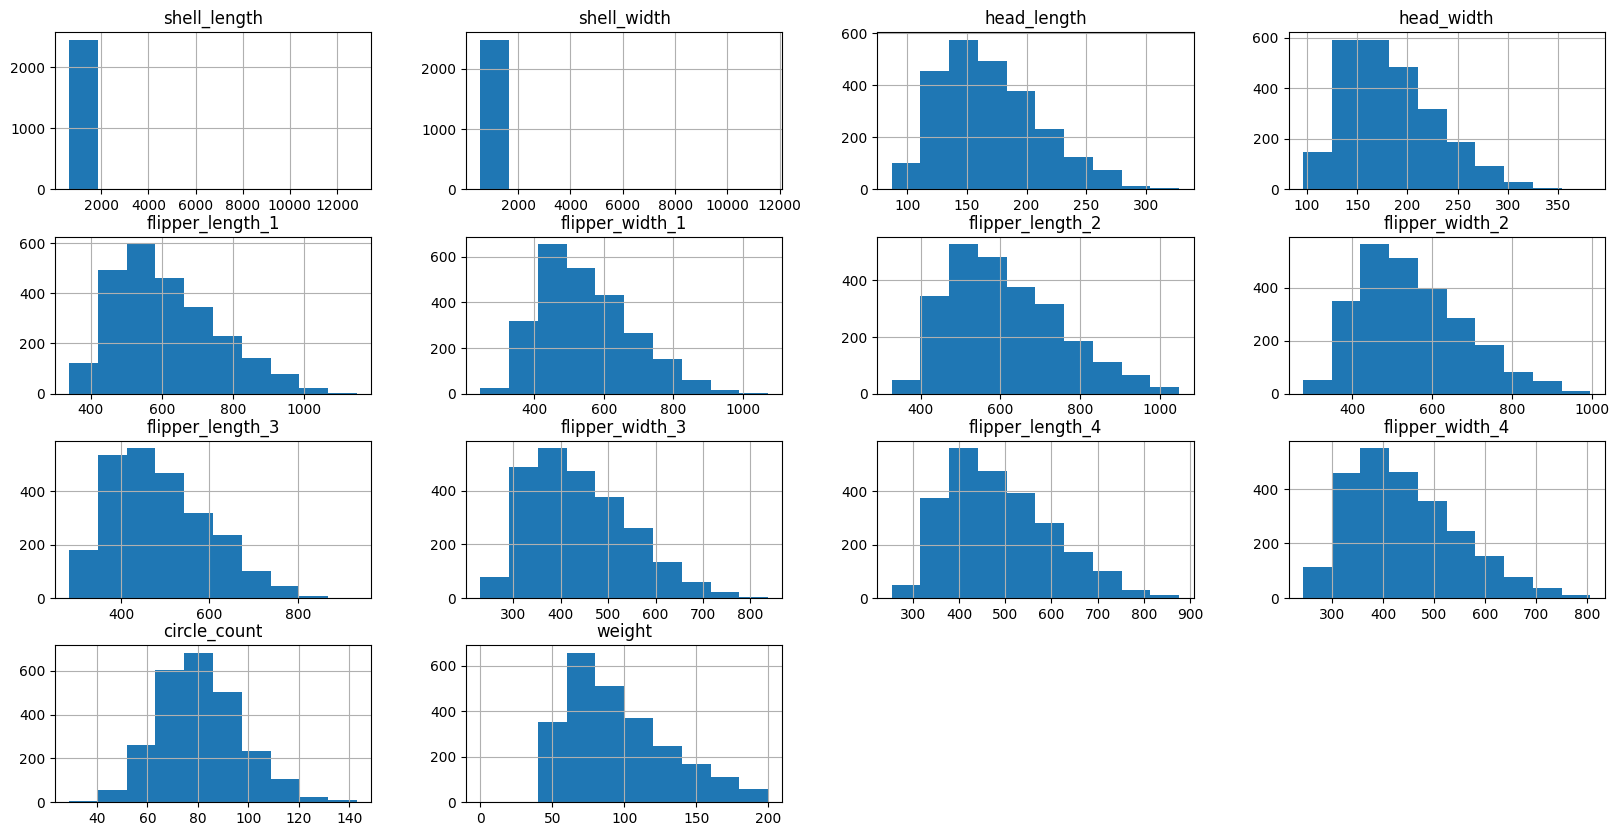

In [24]:
df_chelodia_mydas.hist(figsize=(20, 10));

<Axes: >

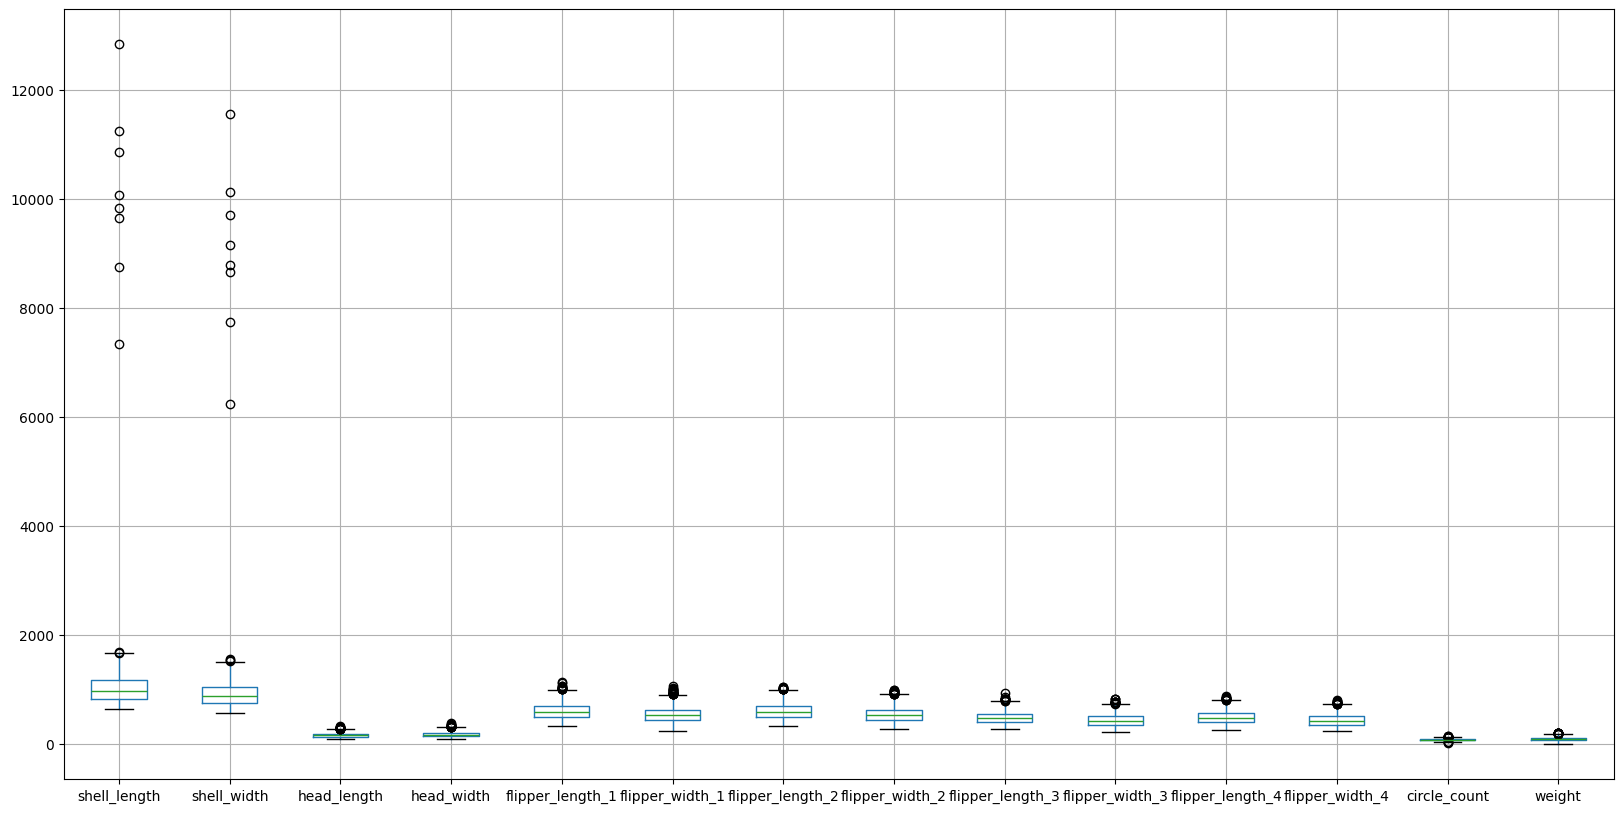

In [25]:
df_chelodia_mydas.boxplot(figsize=(20, 10)) 

In [26]:
df_chelodia_mydas[['shell_length', 'shell_width']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width
count,2457.000000,2486.000000
mean,1047.963745,945.018127
std,568.694885,507.521179
min,645.000000,564.000000
25%,837.000000,752.250000
50%,980.000000,889.000000
75%,1172.000000,1056.000000
95%,1451.000000,1310.750000
99%,1599.880005,1449.350000
max,12840.000000,11550.000000


In [27]:
df_chelodia_mydas['shell_length'] = df_chelodia_mydas['shell_length'].where(df_chelodia_mydas['shell_length'] <= 2000, df_chelodia_mydas['shell_length'] / 10)
df_chelodia_mydas['shell_width'] = df_chelodia_mydas['shell_width'].where(df_chelodia_mydas['shell_width'] <= 2000, df_chelodia_mydas['shell_width'] / 10)

In [28]:
df_chelodia_mydas[['shell_length', 'shell_width']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width
count,2457.000000,2486.000000
mean,1018.436279,918.970215
std,222.149475,203.241547
min,645.000000,564.000000
25%,837.000000,752.000000
50%,979.000000,887.000000
75%,1168.000000,1054.000000
95%,1442.599976,1299.750000
99%,1579.880005,1423.450000
max,1683.000000,1554.000000


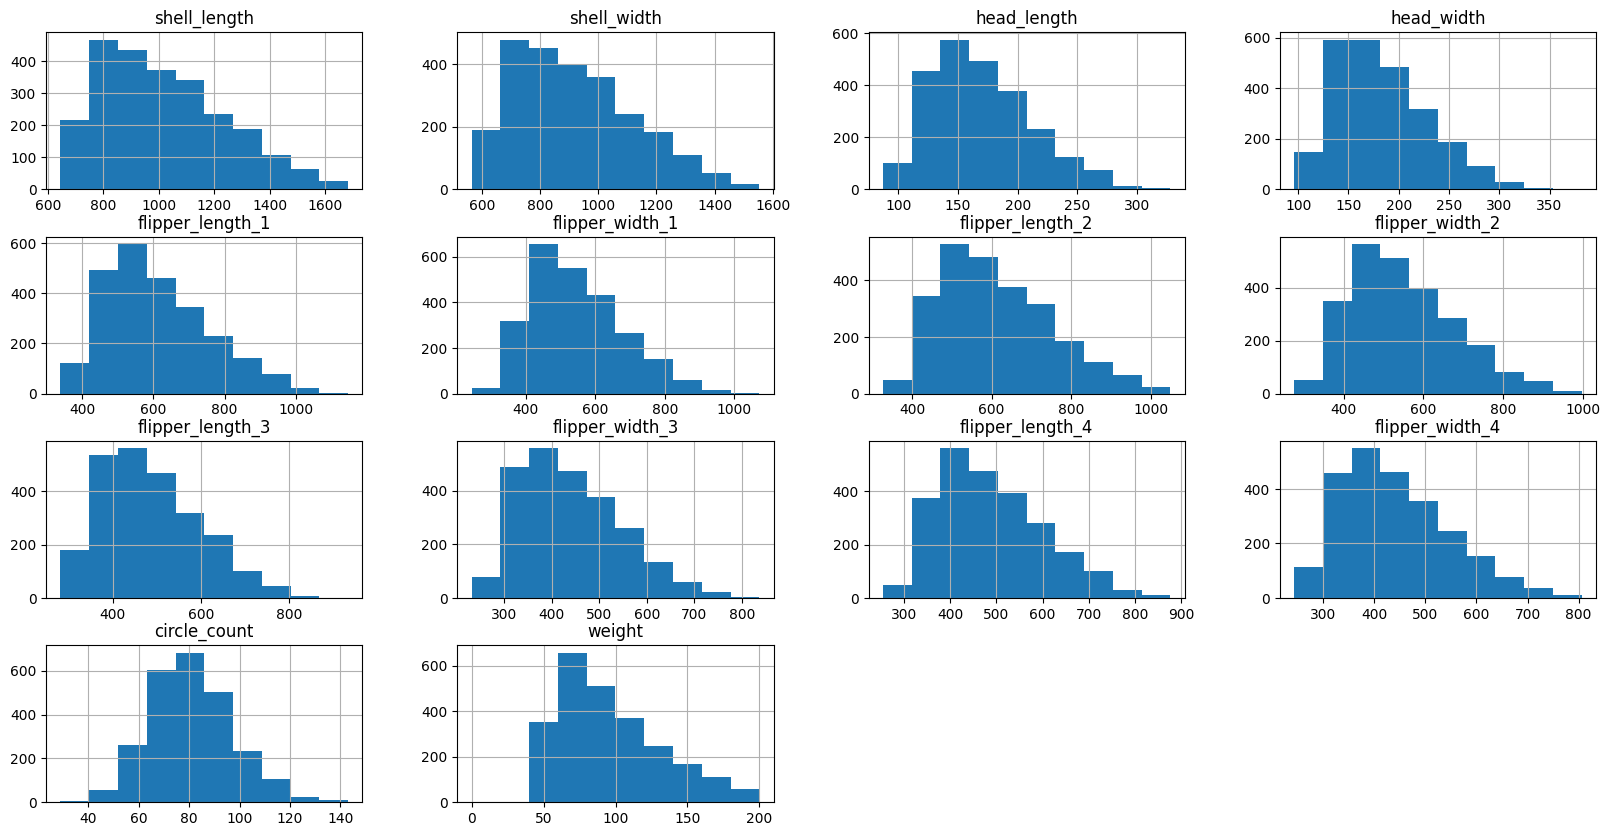

In [29]:
df_chelodia_mydas.hist(figsize=(20, 10));

<Axes: >

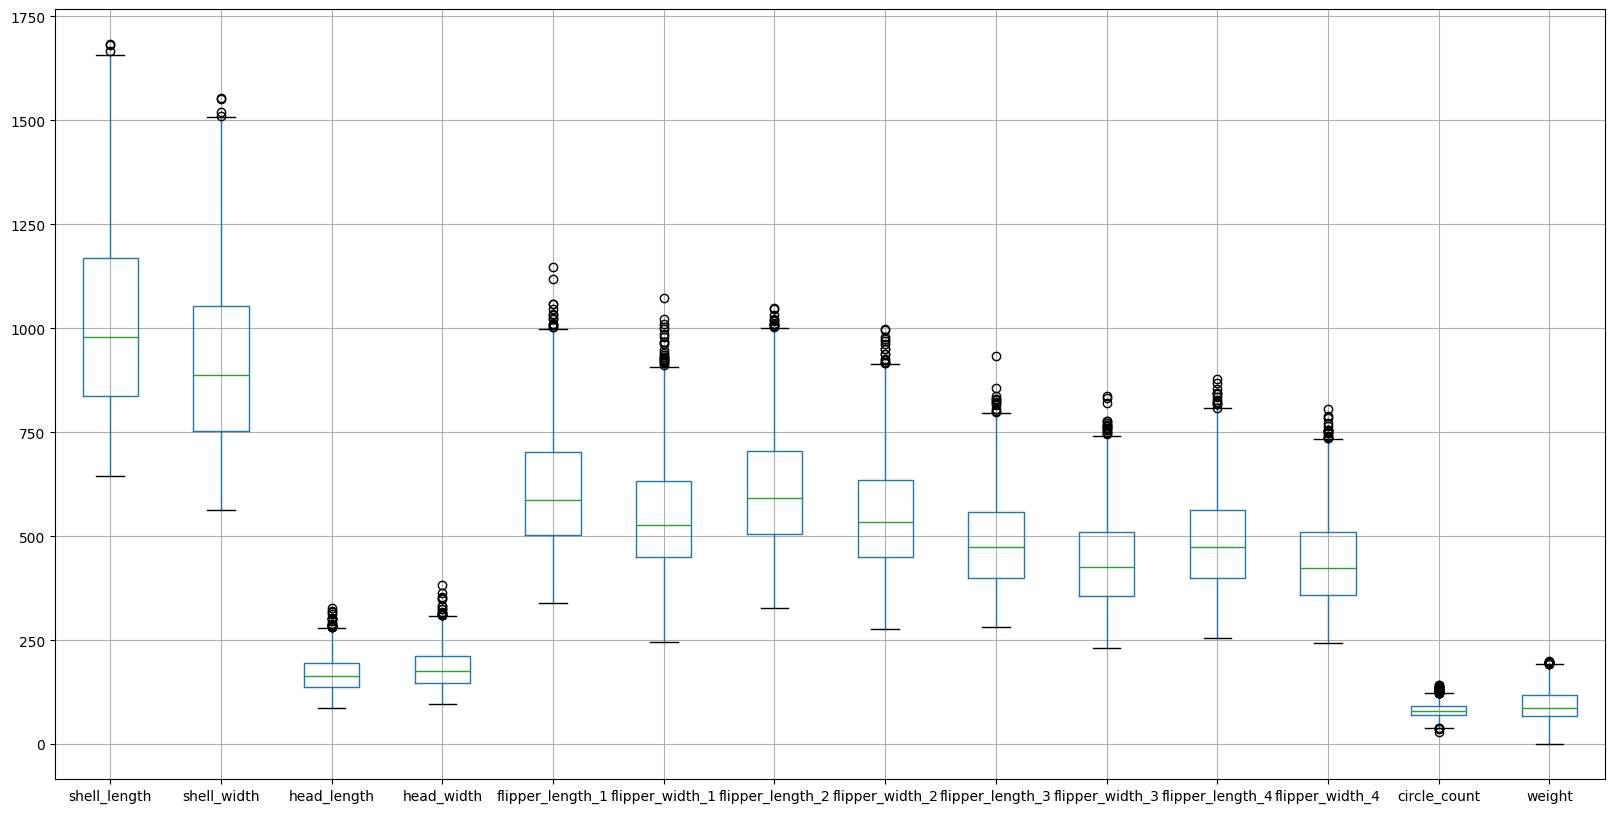

In [30]:
df_chelodia_mydas.boxplot(figsize=(20, 10)) 

### Комментарий

Для анализа распределения признаков были выведены их численные характеристики методов `describe()`, построены гистограммы распределений и визуализация "ящик с усами". Было установлено, что признаки `shell_length` и `shell_width` имеют значительные выбросы, превышающие их 99-й перцентиль. Для длины значение 99-го перцентиля составляет **1599.88 мм**, для ширины **1449.35 мм**. Минимальные значения выбросов превышали **6 метров (6000 мм)**.  
Это совпадает с сообщениям от заказчиков проекта об ошибочном умножении части значений на 10. Действительно длина и ширина черепахи более 6 метров выглядит неправдопообно. В качестве отсечки было выбрано значение **2000 мм**, так как на графике размаха ящик с усами большинство значений было ниже этого порога, а точки выбросов начинались после 6000 мм. Эти значения были поделены на 10, после чего их распеределение стало выглядеть намного более гладким и близким к реальности: максимальная длина черепахи не превышает **1599 мм**, а ширина **1448 мм**.
_________


In [31]:
# measure_cols = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'measure_count', 'shell_crack']
# df_chelodia_mydas[measure_cols].corr(method='pearson').style.background_gradient(cmap='coolwarm')# 

### Комментарий

Для того, чтобы определить какие признаки нам нужны для решения задачи, а какие мы можем удалить, была построена корреляционная матрица с коэффициентом Пирсона. Матрица показала крайне высокую корреляцию длины `shell_length` и ширины панциря `shell_width` (**0.99**), сильную корреляцию (**от 0.77 до 0.87**) группы признаков `head_length`, `head_width` со всеми метриками по длине и ширине плавников (`flipper_length` и `flipper_width`). Также наблюдается очень сильная корреляция числа колец `circle_count` и наличия трещин в панцире `shell_crack` (**0.86**).

На основании анализа матрицы корреляций принято решение удалить `shell_length` и оставить `shell_width`, так как у данных по ширине панциря отсутсвуют пропуски, тогда как в поле длины они есть. Из всей группы признаков по длине и ширине головы и плавников оставить только длину головы `head_length` по причине того, что если прогнозная модель строится для удаленной оценки массы черепахи через портативную систему компьютерного зрения, то съемка и замер головы будет наиболее надежным и котролируемым параметром при сборе метрик в естественной среде обитания черепах. Есть съемка головы - есть параметр для оценки массы.  

В паре число колец `circle_count` и наличие трещин `shell_crack` можно выбросить замер по трещинам, так как в нём содержится большое количество пропусков. Также можно предположить с возрастом у черепахи увеличивается число колец и появляются трещины на панцире. Оба признака косвенно говорят о возрасте животного, поэтому можно оставить один.

Также мы можем избавится от 

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.